# SIS, periodic
{func}`.SIS_Periodic`

This is an extension of the SIS model which incorporates a periodic infection rate, $\beta(t)$.
This could be used to mimic seasonal variation in infectivity due to yearly contact rate patterns or climate drivers, for example.
We define $\beta(t)$ as follows:

$$\begin{aligned}
\beta(t) &= \beta_0 \left(1+\delta \cos \left(\frac{2 \pi t}{P} \right) \right)
\end{aligned}$$

where $\beta_0$ is the baseline infection rate, $\delta$ is the magnitude of oscillations from the baseline ($-1<\delta<1$ so that $\beta>0$) and $P$ is the period of oscillations.

Also, note how we can use $I+S=N$ to eliminate the equation for $S$:

$$\begin{aligned}
\frac{\mathrm{d}I}{\mathrm{d}t} &= (\beta(t)N - \alpha) I - \beta(t)I^{2} \\
\end{aligned}$$

In Heathcote's classical model, $\gamma=1$ and:

$$\begin{aligned}
\beta(t) &=  2 - 1.8 \cos(5t) \\
&=  2\left(1 - 0.9 \cos \left( \frac{2 \pi t}{ \frac{2 \pi}{5} } \right) \right)
\end{aligned}$$

so that $\beta_0=2$, $\delta=0.9$ and $P=\frac{2 \pi}{5}$.

In [7]:
from pygom import common_models
import matplotlib.pyplot as plt
import numpy as np
import math

# Set up PyGOM object
n_pop = 1e4

model = common_models.SIS_Periodic(
    {
        'gamma': 1,
        'beta0': 2,
        'delta': 0.9,
        'period': (2*math.pi/5), 'N':n_pop
    }
)

# Time range and increments
tmax = 10                               # maximum time over which to run solver
dt = 0.01                               # timestep
t = np.arange(0, tmax, dt)

# Initial conditions
i0 = 0.1 * n_pop
s0 = n_pop - i0
x0 = [s0, i0]

model.initial_values = (x0, t[0])
solution = model.solve_deterministic(t)

We plot the infected trajectory which shows periodic evolution.

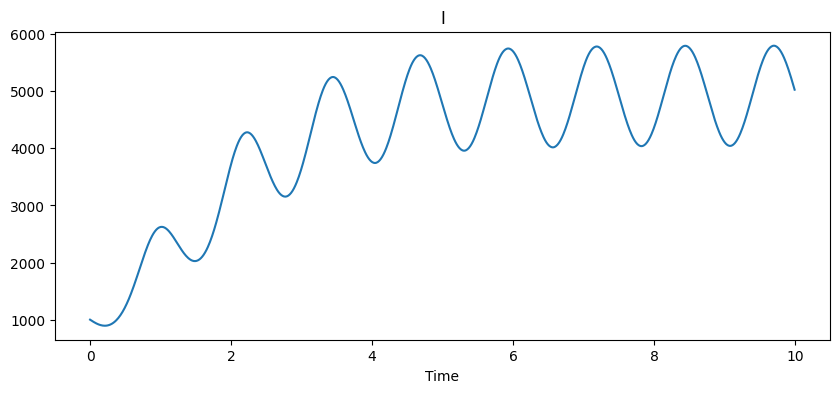

In [8]:
fig, axes = plt.subplots(figsize=(10, 4))

i = 1
axes.set_xlabel("Time")
axes.set_title(model.state_list[i])
axes.plot(t, solution[0].result.y[:, i])
plt.show()